Q2.1: GRADIENT DESCENT ITERATION FORMULA
For g(w) = (w - 1.5)^2:
  ∇g(w) = 2(w - 1.5)
  Gradient Descent update: w_{k+1} = w_k - α * ∇g(w_k)
  w_{k+1} = w_k - 0.2 * 2(w_k - 1.5)
  w_{k+1} = w_k - 0.4(w_k - 1.5)
  w_{k+1} = 0.6w_k + 0.6
  With w_0 = 2:
    w_1 = 0.6*2 + 0.6 = 1.8
    w_2 = 0.6*1.8 + 0.6 = 1.68
    w_3 = 0.6*1.68 + 0.6 = 1.608
    ... converges to w* = 1.5
--------------------------------------------------------------------------------
Q2.2: GRADIENT DESCENT - 10 ITERATIONS
Function: g(w) = (w - 1.5)^2
Initial point: w0 = 2.0
Learning rate: α = 0.2
--------------------------------------------------------------------------------

Iteration |    w_k    |   g(w_k)   |  ∇g(w_k)
------------------------------------------------------------
    0     | 2.00000000 | 0.25000000 | 1.00000000
    1     | 1.80000000 | 0.09000000 | 0.60000000
    2     | 1.68000000 | 0.03240000 | 0.36000000
    3     | 1.60800000 | 0.01166400 | 0.21600000
    4     | 1.56480000 | 0.00419904 | 0.12960

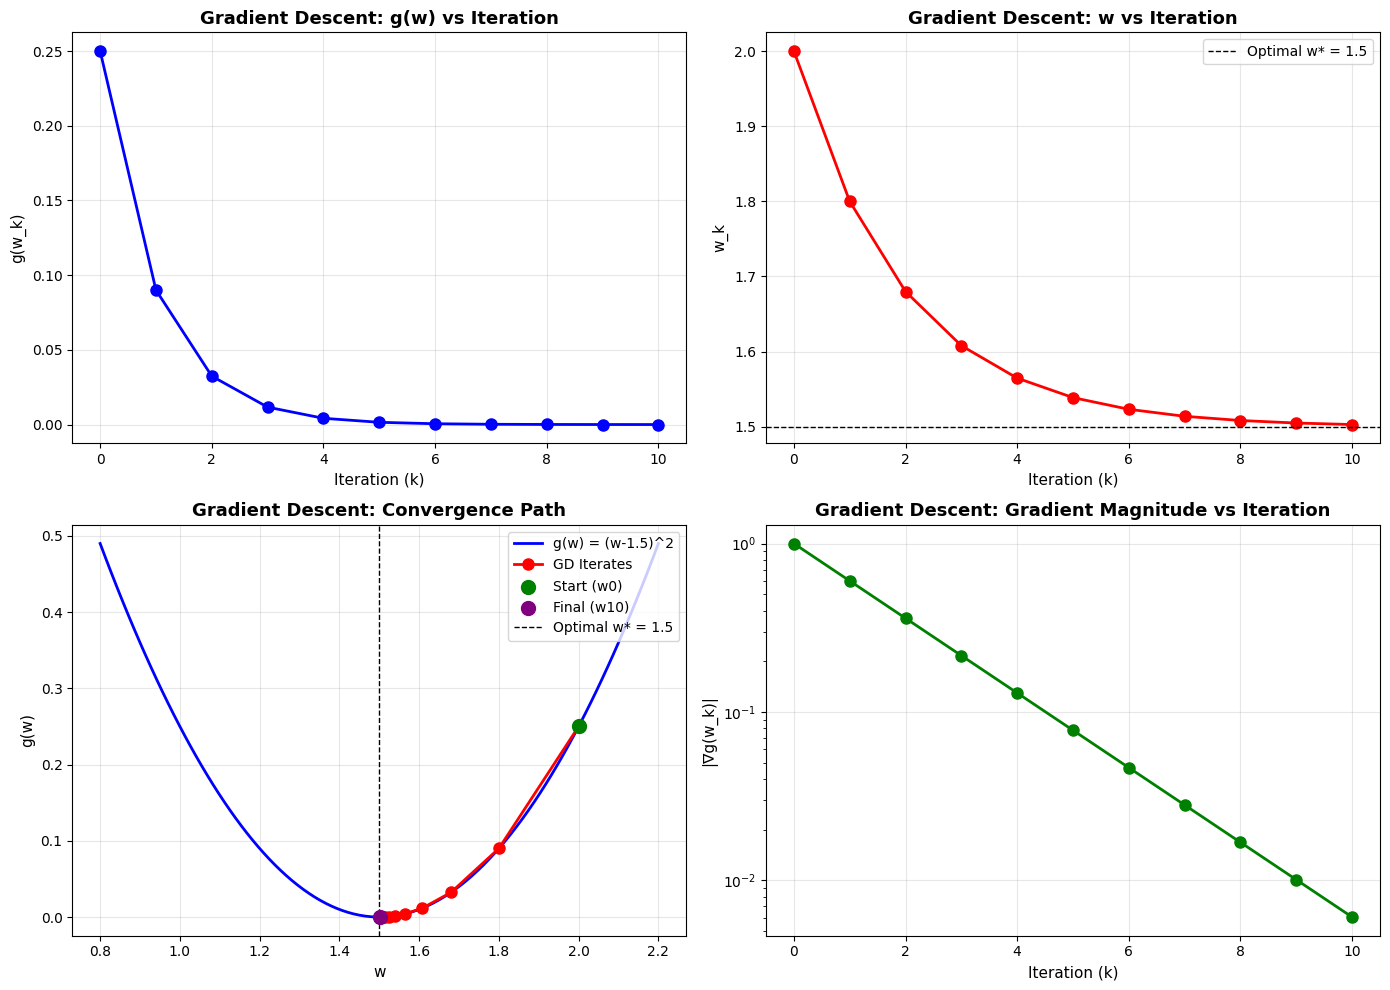


✓ Gradient Descent plots saved as 'gradient_descent_results.png'

Q2.3: ADAM ITERATION FORMULA
Adam update rules for g(w) = (w - 1.5)^2:
  m_k = ρ_f * m_{k-1} + (1 - ρ_f) * ∇g(w_k)
  v_k = ρ * v_{k-1} + (1 - ρ) * (∇g(w_k))^2
  m̂_k = m_k / (1 - ρ_f^k)
  v̂_k = v_k / (1 - ρ^k)
  α_t = α / (√v̂_k + ε)
  w_{k+1} = w_k - α_t * m̂_k
  With w_0 = 2, α = 0.2, ρ = 0.999, ρ_f = 0.9
--------------------------------------------------------------------------------

Q2.4: ADAM OPTIMIZATION - 10 ITERATIONS
Function: g(w) = (w - 1.5)^2
Initial point: w0 = 2.0
Learning rate: α = 0.2
Decay parameters: ρ = 0.999, ρ_f = 0.9
--------------------------------------------------------------------------------

Iteration |    w_k    |   A_k (α_t)  |   g(w_k)   |  ∇g(w_k)
--------------------------------------------------------------------------------
    0     | 2.00000000 |   0.000000 | 0.25000000 | 1.00000000
    1     | 1.80000000 |   0.200000 | 0.09000000 | 0.60000000
    2     | 1.60850197 |   0.242564 | 

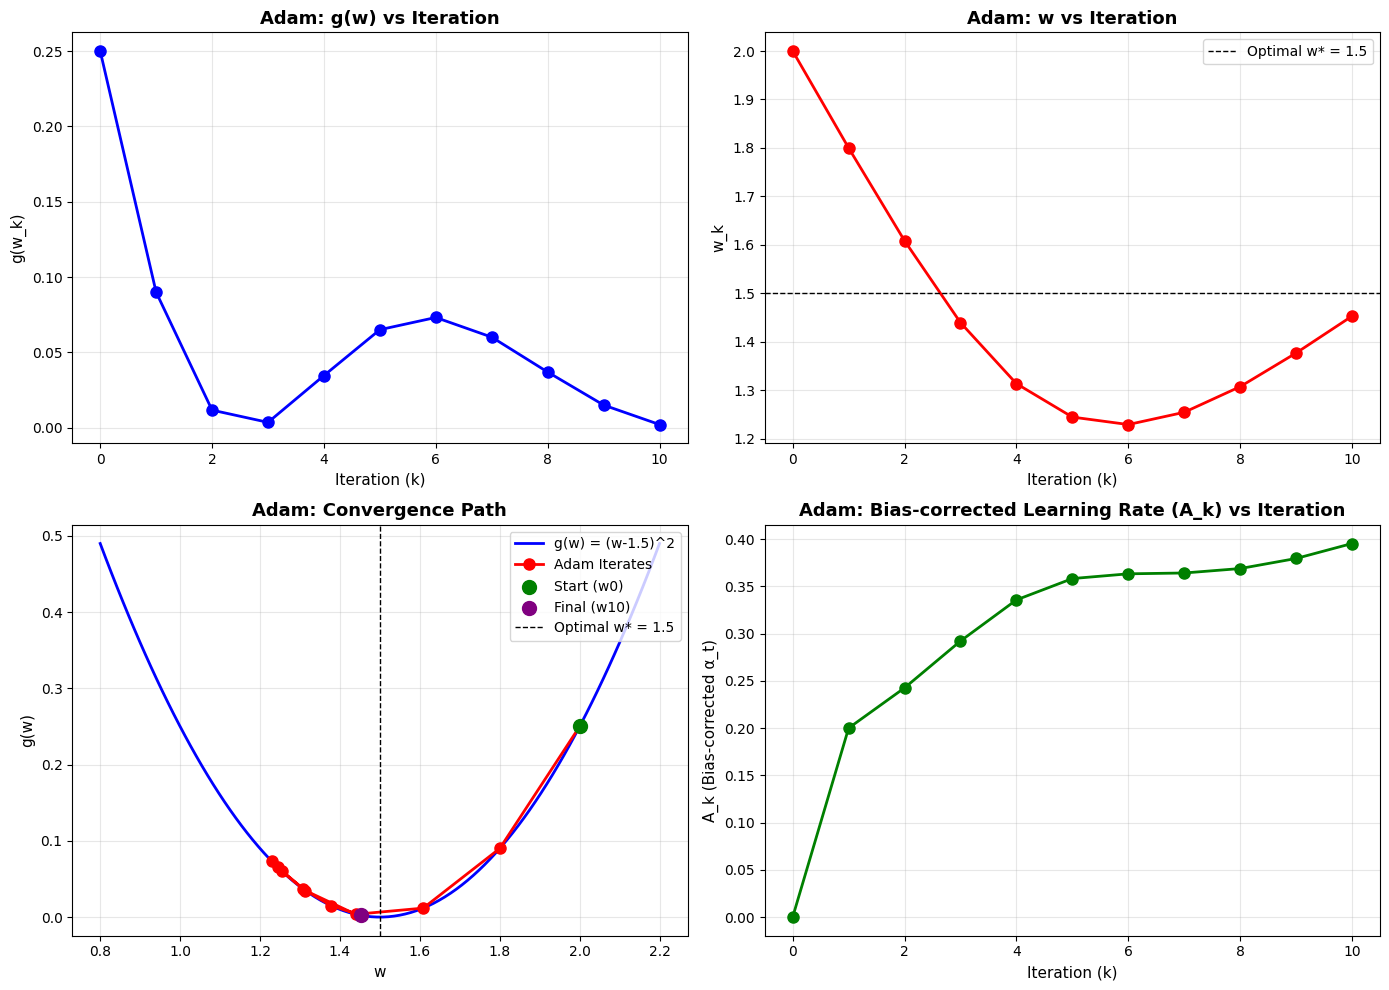


✓ Adam results plots saved as 'adam_results.png'

COMPARISON: GRADIENT DESCENT vs ADAM


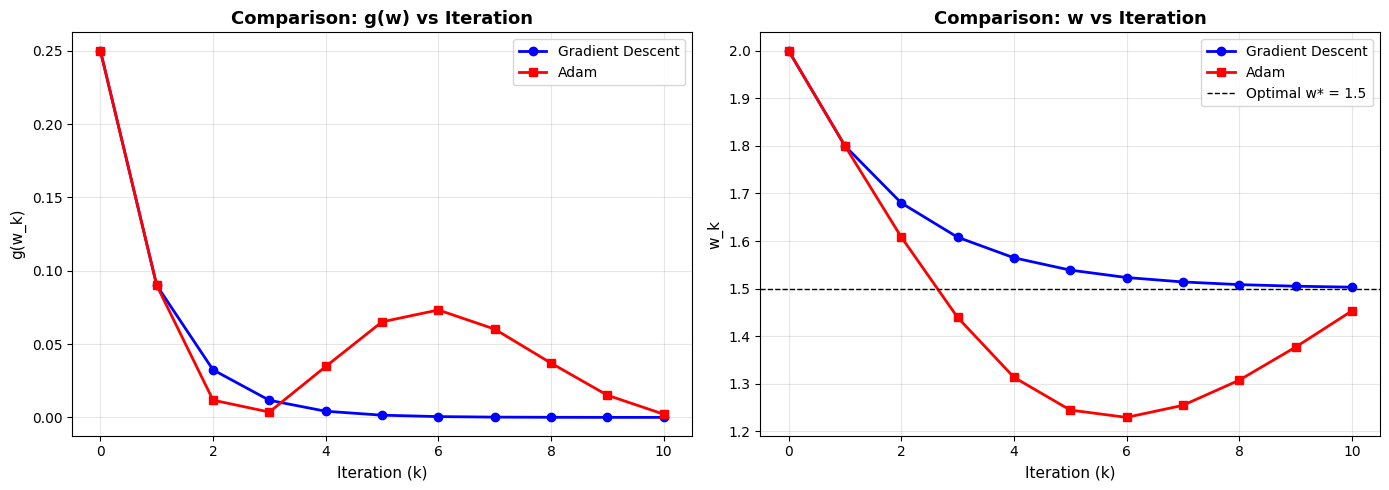


✓ Comparison plots saved as 'comparison_gd_vs_adam.png'

--------------------------------------------------------------------------------
CONVERGENCE SUMMARY
--------------------------------------------------------------------------------
Gradient Descent - Final w: 1.50302331, Final g(w): 0.00000914
Adam           - Final w: 1.45306753, Final g(w): 0.00220266
Optimal solution: w* = 1.5, g(w*) = 0.0

END OF Q2 REPORT


In [3]:
"""
Q2: Gradient Descent and Adam for Quadratic Function
g(w) = (w - 1.5)^2, w ∈ [1, 2]

BITS ID: [Your BITS ID]
"""

import numpy as np
import matplotlib.pyplot as plt

# ============================================================================
# Define the objective function and its gradient
# ============================================================================
def g(w):
    """Objective function: g(w) = (w - 1.5)^2"""
    return (w - 1.5)**2

def gradient_g(w):
    """Gradient of g(w): g'(w) = 2(w - 1.5)"""
    return 2 * (w - 1.5)

# ============================================================================
# Q2.1: Gradient Descent iteration
# ============================================================================
def gradient_descent(w0, learning_rate=0.2, iterations=10):
    """
    Perform Gradient Descent for g(w) = (w - 1.5)^2
    
    Parameters:
    - w0: Initial point (2.0)
    - learning_rate: α = 0.2
    - iterations: Number of iterations (10)
    
    Returns:
    - w_history: List of all w values
    - g_history: List of all function values
    """
    w = w0
    w_history = [w]
    g_history = [g(w)]
    
    for t in range(iterations):
        # Compute gradient
        grad = gradient_g(w)
        
        # Gradient descent update: w_{t+1} = w_t - α * ∇g(w_t)
        w = w - learning_rate * grad
        
        # Store history
        w_history.append(w)
        g_history.append(g(w))
    
    return w_history, g_history

# ============================================================================
# Q2.3: Adam iteration with bias correction
# ============================================================================
def adam(w0, learning_rate=0.2, rho=0.999, rho_f=0.9, iterations=10, epsilon=1e-8):
    """
    Perform Adam optimization for g(w) = (w - 1.5)^2
    
    Parameters:
    - w0: Initial point (2.0)
    - learning_rate: α = 0.2
    - rho: Decay parameter for second moment (ρ = 0.999)
    - rho_f: Decay parameter for first moment (ρ_f = 0.9)
    - iterations: Number of iterations (10)
    - epsilon: Small constant for numerical stability
    
    Returns:
    - w_history: List of all w values
    - m_history: List of first moment estimates (before bias correction)
    - v_history: List of second moment estimates (before bias correction)
    - alpha_t_history: List of bias-corrected learning rates
    - g_history: List of all function values
    - g_w_history: List of gradients at each point
    """
    w = w0
    m = 0  # First moment (mean)
    v = 0  # Second moment (uncentered variance)
    
    w_history = [w]
    m_history = [m]
    v_history = [v]
    alpha_t_history = [0]  # No learning rate at t=0
    g_history = [g(w)]
    g_w_history = [gradient_g(w)]
    
    for t in range(1, iterations + 1):
        # Compute gradient at current w
        grad = gradient_g(w)
        
        # Update biased first moment estimate
        m = rho_f * m + (1 - rho_f) * grad
        
        # Update biased second moment estimate
        v = rho * v + (1 - rho) * grad**2
        
        # Bias correction for first moment
        m_hat = m / (1 - rho_f**t)
        
        # Bias correction for second moment
        v_hat = v / (1 - rho**t)
        
        # Bias-corrected learning rate
        alpha_t = learning_rate / (np.sqrt(v_hat) + epsilon)
        
        # Adam update: w_{t+1} = w_t - α_t * m_hat
        w = w - alpha_t * m_hat
        
        # Store history
        w_history.append(w)
        m_history.append(m.copy() if hasattr(m, 'copy') else m)
        v_history.append(v.copy() if hasattr(v, 'copy') else v)
        alpha_t_history.append(alpha_t)
        g_history.append(g(w))
        g_w_history.append(gradient_g(w))
    
    return w_history, m_history, v_history, alpha_t_history, g_history, g_w_history

# ============================================================================
# Q2.2: Perform Gradient Descent and plot results
# ============================================================================
def run_gradient_descent():
    print("=" * 80)
    print("Q2.2: GRADIENT DESCENT - 10 ITERATIONS")
    print("=" * 80)
    print("Function: g(w) = (w - 1.5)^2")
    print(f"Initial point: w0 = 2.0")
    print(f"Learning rate: α = 0.2")
    print("-" * 80)
    
    # Run gradient descent
    w_history_gd, g_history_gd = gradient_descent(w0=2.0, learning_rate=0.2, iterations=10)
    
    # Tabulate results
    print("\nIteration |    w_k    |   g(w_k)   |  ∇g(w_k)")
    print("-" * 60)
    for k in range(len(w_history_gd)):
        grad = gradient_g(w_history_gd[k])
        print(f"   {k:2d}     | {w_history_gd[k]:.8f} | {g_history_gd[k]:.8f} | {grad:.8f}")
    
    # Plot results
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    # Plot 1: g(w) vs iteration
    iterations_range = range(len(g_history_gd))
    axes[0, 0].plot(iterations_range, g_history_gd, 'b-o', linewidth=2, markersize=8)
    axes[0, 0].set_xlabel('Iteration (k)', fontsize=11)
    axes[0, 0].set_ylabel('g(w_k)', fontsize=11)
    axes[0, 0].set_title('Gradient Descent: g(w) vs Iteration', fontsize=13, fontweight='bold')
    axes[0, 0].grid(True, alpha=0.3)
    
    # Plot 2: w vs iteration
    axes[0, 1].plot(iterations_range, w_history_gd, 'r-o', linewidth=2, markersize=8)
    axes[0, 1].axhline(y=1.5, color='k', linestyle='--', linewidth=1, label='Optimal w* = 1.5')
    axes[0, 1].set_xlabel('Iteration (k)', fontsize=11)
    axes[0, 1].set_ylabel('w_k', fontsize=11)
    axes[0, 1].set_title('Gradient Descent: w vs Iteration', fontsize=13, fontweight='bold')
    axes[0, 1].grid(True, alpha=0.3)
    axes[0, 1].legend()
    
    # Plot 3: Convergence path on function landscape
    w_plot = np.linspace(0.8, 2.2, 100)
    g_plot = g(w_plot)
    axes[1, 0].plot(w_plot, g_plot, 'b-', linewidth=2, label='g(w) = (w-1.5)^2')
    axes[1, 0].plot(w_history_gd, g_history_gd, 'ro-', linewidth=2, markersize=8, label='GD Iterates')
    axes[1, 0].scatter(w_history_gd[0], g_history_gd[0], color='green', s=100, label='Start (w0)', zorder=5)
    axes[1, 0].scatter(w_history_gd[-1], g_history_gd[-1], color='purple', s=100, label='Final (w10)', zorder=5)
    axes[1, 0].axvline(x=1.5, color='k', linestyle='--', linewidth=1, label='Optimal w* = 1.5')
    axes[1, 0].set_xlabel('w', fontsize=11)
    axes[1, 0].set_ylabel('g(w)', fontsize=11)
    axes[1, 0].set_title('Gradient Descent: Convergence Path', fontsize=13, fontweight='bold')
    axes[1, 0].grid(True, alpha=0.3)
    axes[1, 0].legend(loc='upper right')
    
    # Plot 4: Gradient norm vs iteration
    grad_history = [gradient_g(w) for w in w_history_gd]
    axes[1, 1].semilogy(iterations_range, np.abs(grad_history), 'g-o', linewidth=2, markersize=8)
    axes[1, 1].set_xlabel('Iteration (k)', fontsize=11)
    axes[1, 1].set_ylabel('|∇g(w_k)|', fontsize=11)
    axes[1, 1].set_title('Gradient Descent: Gradient Magnitude vs Iteration', fontsize=13, fontweight='bold')
    axes[1, 1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('gradient_descent_results.png', dpi=300, bbox_inches='tight')
    plt.show()
    print("\n✓ Gradient Descent plots saved as 'gradient_descent_results.png'")
    
    return w_history_gd, g_history_gd

# ============================================================================
# Q2.4: Perform Adam optimization and plot results
# ============================================================================
def run_adam():
    print("\n" + "=" * 80)
    print("Q2.4: ADAM OPTIMIZATION - 10 ITERATIONS")
    print("=" * 80)
    print("Function: g(w) = (w - 1.5)^2")
    print(f"Initial point: w0 = 2.0")
    print(f"Learning rate: α = 0.2")
    print(f"Decay parameters: ρ = 0.999, ρ_f = 0.9")
    print("-" * 80)
    
    # Run Adam optimization
    w_history_adam, m_history, v_history, alpha_t_history, g_history_adam, grad_history_adam = adam(
        w0=2.0, learning_rate=0.2, rho=0.999, rho_f=0.9, iterations=10
    )
    
    # Tabulate results (Q2.4: w_k, A_k, g(w_k))
    print("\nIteration |    w_k    |   A_k (α_t)  |   g(w_k)   |  ∇g(w_k)")
    print("-" * 80)
    for k in range(len(w_history_adam)):
        grad = grad_history_adam[k]
        alpha_t = alpha_t_history[k] if k < len(alpha_t_history) else 0
        # A_k is the bias-corrected learning rate
        print(f"   {k:2d}     | {w_history_adam[k]:.8f} | {alpha_t:10.6f} | {g_history_adam[k]:.8f} | {grad:.8f}")
    
    # Plot results
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    iterations_range = range(len(g_history_adam))
    
    # Plot 1: g(w) vs iteration
    axes[0, 0].plot(iterations_range, g_history_adam, 'b-o', linewidth=2, markersize=8)
    axes[0, 0].set_xlabel('Iteration (k)', fontsize=11)
    axes[0, 0].set_ylabel('g(w_k)', fontsize=11)
    axes[0, 0].set_title('Adam: g(w) vs Iteration', fontsize=13, fontweight='bold')
    axes[0, 0].grid(True, alpha=0.3)
    
    # Plot 2: w vs iteration
    axes[0, 1].plot(iterations_range, w_history_adam, 'r-o', linewidth=2, markersize=8)
    axes[0, 1].axhline(y=1.5, color='k', linestyle='--', linewidth=1, label='Optimal w* = 1.5')
    axes[0, 1].set_xlabel('Iteration (k)', fontsize=11)
    axes[0, 1].set_ylabel('w_k', fontsize=11)
    axes[0, 1].set_title('Adam: w vs Iteration', fontsize=13, fontweight='bold')
    axes[0, 1].grid(True, alpha=0.3)
    axes[0, 1].legend()
    
    # Plot 3: Convergence path on function landscape
    w_plot = np.linspace(0.8, 2.2, 100)
    g_plot = g(w_plot)
    axes[1, 0].plot(w_plot, g_plot, 'b-', linewidth=2, label='g(w) = (w-1.5)^2')
    axes[1, 0].plot(w_history_adam, g_history_adam, 'ro-', linewidth=2, markersize=8, label='Adam Iterates')
    axes[1, 0].scatter(w_history_adam[0], g_history_adam[0], color='green', s=100, label='Start (w0)', zorder=5)
    axes[1, 0].scatter(w_history_adam[-1], g_history_adam[-1], color='purple', s=100, label='Final (w10)', zorder=5)
    axes[1, 0].axvline(x=1.5, color='k', linestyle='--', linewidth=1, label='Optimal w* = 1.5')
    axes[1, 0].set_xlabel('w', fontsize=11)
    axes[1, 0].set_ylabel('g(w)', fontsize=11)
    axes[1, 0].set_title('Adam: Convergence Path', fontsize=13, fontweight='bold')
    axes[1, 0].grid(True, alpha=0.3)
    axes[1, 0].legend(loc='upper right')
    
    # Plot 4: Bias-corrected learning rate (α_t) vs iteration
    axes[1, 1].plot(iterations_range, alpha_t_history, 'g-o', linewidth=2, markersize=8)
    axes[1, 1].set_xlabel('Iteration (k)', fontsize=11)
    axes[1, 1].set_ylabel('A_k (Bias-corrected α_t)', fontsize=11)
    axes[1, 1].set_title('Adam: Bias-corrected Learning Rate (A_k) vs Iteration', fontsize=13, fontweight='bold')
    axes[1, 1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('adam_results.png', dpi=300, bbox_inches='tight')
    plt.show()
    print("\n✓ Adam results plots saved as 'adam_results.png'")
    
    return w_history_adam, alpha_t_history, g_history_adam

# ============================================================================
# Comparison: Gradient Descent vs Adam
# ============================================================================
def compare_methods(w_history_gd, g_history_gd, w_history_adam, g_history_adam):
    print("\n" + "=" * 80)
    print("COMPARISON: GRADIENT DESCENT vs ADAM")
    print("=" * 80)
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Plot 1: g(w) vs iteration comparison
    iterations_range = range(max(len(g_history_gd), len(g_history_adam)))
    
    # Only plot up to the minimum length for fair comparison
    min_len = min(len(g_history_gd), len(g_history_adam))
    axes[0].plot(range(min_len), g_history_gd[:min_len], 'b-o', linewidth=2, markersize=6, label='Gradient Descent')
    axes[0].plot(range(min_len), g_history_adam[:min_len], 'r-s', linewidth=2, markersize=6, label='Adam')
    axes[0].set_xlabel('Iteration (k)', fontsize=11)
    axes[0].set_ylabel('g(w_k)', fontsize=11)
    axes[0].set_title('Comparison: g(w) vs Iteration', fontsize=13, fontweight='bold')
    axes[0].grid(True, alpha=0.3)
    axes[0].legend()
    
    # Plot 2: w vs iteration comparison
    axes[1].plot(range(min_len), w_history_gd[:min_len], 'b-o', linewidth=2, markersize=6, label='Gradient Descent')
    axes[1].plot(range(min_len), w_history_adam[:min_len], 'r-s', linewidth=2, markersize=6, label='Adam')
    axes[1].axhline(y=1.5, color='k', linestyle='--', linewidth=1, label='Optimal w* = 1.5')
    axes[1].set_xlabel('Iteration (k)', fontsize=11)
    axes[1].set_ylabel('w_k', fontsize=11)
    axes[1].set_title('Comparison: w vs Iteration', fontsize=13, fontweight='bold')
    axes[1].grid(True, alpha=0.3)
    axes[1].legend()
    
    plt.tight_layout()
    plt.savefig('comparison_gd_vs_adam.png', dpi=300, bbox_inches='tight')
    plt.show()
    print("\n✓ Comparison plots saved as 'comparison_gd_vs_adam.png'")
    
    # Print convergence summary
    print("\n" + "-" * 80)
    print("CONVERGENCE SUMMARY")
    print("-" * 80)
    print(f"Gradient Descent - Final w: {w_history_gd[-1]:.8f}, Final g(w): {g_history_gd[-1]:.8f}")
    print(f"Adam           - Final w: {w_history_adam[-1]:.8f}, Final g(w): {g_history_adam[-1]:.8f}")
    print(f"Optimal solution: w* = 1.5, g(w*) = 0.0")

# ============================================================================
# MAIN EXECUTION
# ============================================================================
if __name__ == "__main__":
    
    # Q2.1: Show the Gradient Descent iteration
    print("=" * 80)
    print("Q2.1: GRADIENT DESCENT ITERATION FORMULA")
    print("=" * 80)
    print("For g(w) = (w - 1.5)^2:")
    print("  ∇g(w) = 2(w - 1.5)")
    print("  Gradient Descent update: w_{k+1} = w_k - α * ∇g(w_k)")
    print("  w_{k+1} = w_k - 0.2 * 2(w_k - 1.5)")
    print("  w_{k+1} = w_k - 0.4(w_k - 1.5)")
    print("  w_{k+1} = 0.6w_k + 0.6")
    print("  With w_0 = 2:")
    print("    w_1 = 0.6*2 + 0.6 = 1.8")
    print("    w_2 = 0.6*1.8 + 0.6 = 1.68")
    print("    w_3 = 0.6*1.68 + 0.6 = 1.608")
    print("    ... converges to w* = 1.5")
    print("-" * 80)
    
    # Q2.2: Run Gradient Descent and plot
    w_history_gd, g_history_gd = run_gradient_descent()
    
    # Q2.3: Show Adam iteration formula
    print("\n" + "=" * 80)
    print("Q2.3: ADAM ITERATION FORMULA")
    print("=" * 80)
    print("Adam update rules for g(w) = (w - 1.5)^2:")
    print("  m_k = ρ_f * m_{k-1} + (1 - ρ_f) * ∇g(w_k)")
    print("  v_k = ρ * v_{k-1} + (1 - ρ) * (∇g(w_k))^2")
    print("  m̂_k = m_k / (1 - ρ_f^k)")
    print("  v̂_k = v_k / (1 - ρ^k)")
    print("  α_t = α / (√v̂_k + ε)")
    print("  w_{k+1} = w_k - α_t * m̂_k")
    print(f"  With w_0 = 2, α = 0.2, ρ = 0.999, ρ_f = 0.9")
    print("-" * 80)
    
    # Q2.4: Run Adam and plot
    w_history_adam, alpha_t_history, g_history_adam = run_adam()
    
    # Compare both methods
    compare_methods(w_history_gd, g_history_gd, w_history_adam, g_history_adam)
    
    print("\n" + "=" * 80)
    print("END OF Q2 REPORT")
    print("=" * 80)